In [3]:
## Acest dataset contine informatii legate de intarzierile trenurilor de pe reteaua feroviara din Polonia.
## Datele sunt organizate in acest set de date in felul urmator: datetime - data la care a fost inregistrata intarzierea, id - identificatorul trenului, date - data la care trenul pleaca din prima gara, connection - ruta pe care opereaza trenul, carrier - operatorul feroviar, arrival - ora la care trebuie sa ajunga in statia terminus, ##delay - intarzierea, name - numele garii

## Acest dataset acopera reteaua feroviara timp de doua saptamani, intre 12AM 16.05.2022 si 12AM 30.05.2022. Observatiile, mai precis datele, au fost colectate intr-un interval de 5 minute.


## Pentru D1 trebuie sa exploram dataset-ul.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
print(sys.executable)

C:\Users\todit\.conda\envs\PolishTrainDelaysML\python.exe


In [4]:
df = pd.read_csv("data/delays.csv")
print(pd.__version__) ##testare pandas
print(np.__version__) ##testare numpy

3.0.1
2.4.4


In [5]:
print(df) ##testare conexiune cu dataset

                    datetime                      id             carrier  \
0        2022-05-16 00:00:00   41002/3 (102) POLONIA       PKP Intercity   
1        2022-05-16 00:00:00          91888/9 (102)   Koleje Mazowieckie   
2        2022-05-16 00:00:00          21644/5 (102)   Koleje Mazowieckie   
3        2022-05-16 00:00:00          19300/1 (102)   Koleje Mazowieckie   
4        2022-05-16 00:00:00  38170/1 (102) USTRONIE       PKP Intercity   
...                      ...                     ...                 ...   
3718165  2022-05-29 23:55:00        53172/3  ROZEWIE       PKP Intercity   
3718166  2022-05-29 23:55:00                 15417    Koleje Mazowieckie   
3718167  2022-05-29 23:55:00       38170/1  USTRONIE       PKP Intercity   
3718168  2022-05-29 23:55:00       83170/1  USTRONIE       PKP Intercity   
3718169  2022-05-29 23:55:00        35170/1  KARPATY       PKP Intercity   

               date                                connection arrival  \
0        2022-

In [6]:
print(df.shape)

(3718170, 8)


print(df.shape) afiseaza practic forma datasetului, mai precis numarul de randuri si numarul de coloane. In cazul nostru, sunt 3718170 de randuri si 8 coloane.

In [7]:
print(df.columns)

Index(['datetime', 'id', 'carrier', 'date', 'connection', 'arrival', 'delay',
       'name'],
      dtype='str')


print(df.columns) afiseaza coloanele datasetului. In cazul nostru sunt 8 coloane, precizate in comment-ul din primul cell.

In [8]:
print(df.head())

              datetime                      id             carrier  \
0  2022-05-16 00:00:00   41002/3 (102) POLONIA       PKP Intercity   
1  2022-05-16 00:00:00          91888/9 (102)   Koleje Mazowieckie   
2  2022-05-16 00:00:00          21644/5 (102)   Koleje Mazowieckie   
3  2022-05-16 00:00:00          19300/1 (102)   Koleje Mazowieckie   
4  2022-05-16 00:00:00  38170/1 (102) USTRONIE       PKP Intercity   

         date                                connection arrival    delay  \
0  2022-05-15              Bohumin - Warszawa Wschodnia   21:31  162 min   
1  2022-05-16              Siedlce - Warszawa Zachodnia   00:15    0 min   
2  2022-05-16         Radom Główny - Warszawa Wschodnia   00:29    0 min   
3  2022-05-16  Warszawa Wschodnia - Grodzisk Mazowiecki   00:34    0 min   
4  2022-05-16                 Kraków Główny - Kołobrzeg   00:55    0 min   

                 name  
0  Warszawa Zachodnia  
1  Warszawa Zachodnia  
2  Warszawa Zachodnia  
3  Warszawa Zachodnia  
4 

Aici sunt afisate primele randuri din dataSet

In [9]:
print(df.describe())

                   datetime                 id        carrier        date  \
count               3718170            3718170        3718170     3718170   
unique                 4032               7947             10          16   
top     2022-05-20 06:15:00  38170/1  USTRONIE  PKP Intercity  2022-05-20   
freq                   1525              17567        1271352      283902   

               connection  arrival    delay      name  
count             3718170  3718170  3718170   3718170  
unique                995     1391      358        95  
top     Pruszków - Otwock    07:05    0 min  Żyrardów  
freq               138074     7861  2834968    124841  


Metoda .describe() are rolul de arata statisticile dataset-ului.

In [10]:
print(df.isnull().sum())

datetime      0
id            0
carrier       0
date          0
connection    0
arrival       0
delay         0
name          0
dtype: int64


Are rolul de arata valorile lipsa din dataset.

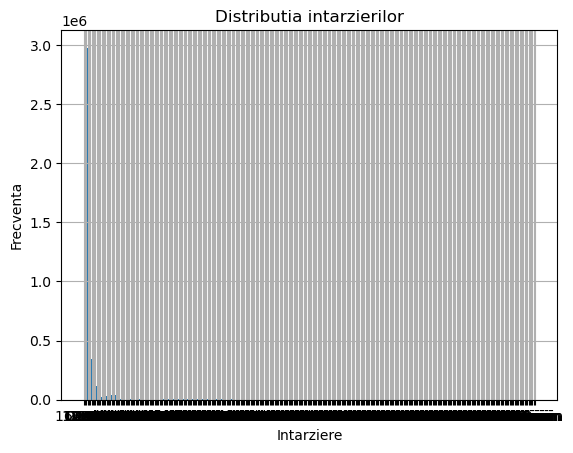

In [11]:
df["delay"].hist(bins=100)
plt.title("Distributia intarzierilor")
plt.xlabel("Intarziere")
plt.ylabel("Frecventa")
plt.show()

Grafic pentru cele mai frecvente intarzieri.

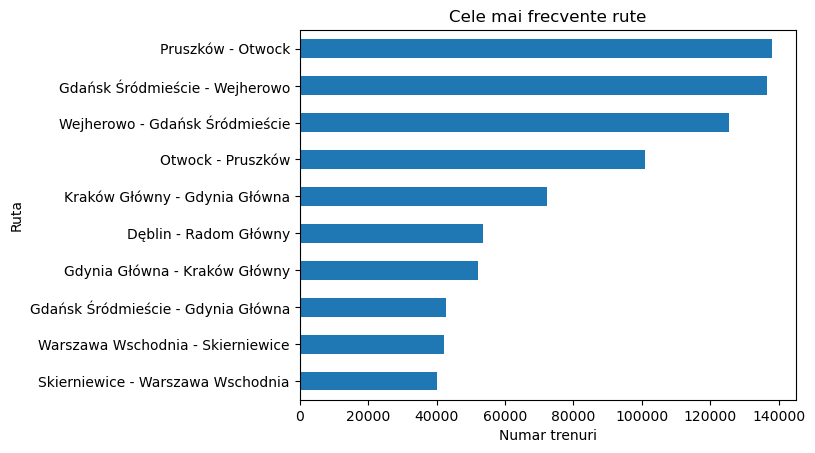

In [12]:
top_routes = df["connection"].value_counts().head(10)
top_routes.sort_values().plot(kind="barh")
plt.title("Cele mai frecvente rute")
plt.xlabel("Numar trenuri")
plt.ylabel("Ruta")
plt.show()



Cele mai frecvente trenuri de pe reteaua feroviara poloneza.

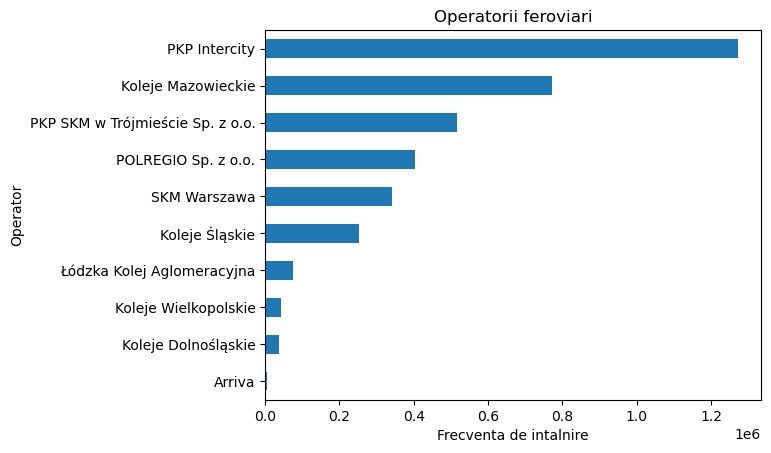

In [15]:
top_operators = df["carrier"].value_counts().head(10)
top_operators.sort_values().plot(kind="barh")
plt.title("Operatorii feroviari")
plt.xlabel("Frecventa de intalnire")
plt.ylabel("Operator")
plt.show()

Grafic care arata numarul de curse al fiecarui operator feroviar din Polonia. Nota : PKP Intercity este operatorul feroviar NATIONAL al Poloniei, restul sunt OTF privati.